## Homework : Financial Ratio Quantile Strategies
##### - Name : Dipesh Ghimire | CNET ID : dipeshg | Date: January 27, 2026

This notebook implements quantile-based long-short trading strategies using financial accounting ratios.
The analysis covers January 2018 through June 2023.

## Data Preprocessing

In [189]:
import numpy as np
import polars as pl
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

### Define the Universe

We construct an investable universe based on the following criteria:
1. End-of-day adjusted closing prices available for entire period (Jan 2018 - Jun 2023)
2. Market value never dips below $100MM
3. Debt/market cap ratio > 0.1 at some point
4. Not in automotive, financial, or insurance sectors
5. Feasible calculation of all three ratios throughout the period

#### Filter for Complete Coverage
- end-of-day adjusted closing prices are available, over the entire period Jan 2018 through Jun 2023 <br>
This implements the requirement for "end-of-day adjusted closing prices available over the entire period."

In [190]:
# Load daily stock prices and filter by the date range (Jan 2018 - Jun 2023)
prices = pl.read_csv(
    'data/ZacksFundamentalsB/QUOTEMEDIA_PRICES_247f636d651d8ef83d8ca1e756cf5ee4.csv'
).filter(
    (pl.col("date") >= "2018-01-01") & (pl.col("date") <= "2023-06-30")
)

# Get all unique dates in the filtered period
unique_dates = prices.select("date").unique().sort("date")

# For each unique date, get the set of tickers that have adjusted close prices
ticker_sets_by_date = []
for date_row in unique_dates.iter_rows(named=True):
    date_value = date_row["date"]
    # Get tickers that have non-null adjusted close price on this date
    tickers_on_date = set(
        prices.filter(
            (pl.col("date") == date_value) & 
            (pl.col("adj_close").is_not_null())
        )
        .get_column("ticker")
        .to_list()
    )
    ticker_sets_by_date.append(tickers_on_date)

# Find tickers that have data on every single trading day in the period by taking the intersection of all ticker sets across all dates
complete_tickers = set.intersection(*ticker_sets_by_date) if ticker_sets_by_date else set()

# Retain those tickers with end-of-day adjusted closing prices over the entire period
prices = prices.filter(pl.col("ticker").is_in(complete_tickers))

# Display the first few rows for prices dataframe
prices.head()

ticker,date,open,high,low,close,volume,dividend,split,adj_open,adj_high,adj_low,adj_close,adj_volume
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""FLWS""","""2022-03-09""",14.57,14.9588,14.41,14.45,662492.0,0.0,1.0,14.57,14.9588,14.41,14.45,662492.0
"""VNET""","""2022-03-09""",6.6,6.925,6.455,6.78,1.483583e6,0.0,1.0,6.6,6.925,6.455,6.78,1.483583e6
"""AAPL""","""2022-03-01""",164.695,166.6,161.97,163.2,8.3063644e7,0.0,1.0,162.43085,164.309661,159.743312,160.956403,8.3063644e7
"""DDD""","""2022-03-09""",14.88,15.35,14.5,15.28,1.991829e6,0.0,1.0,14.88,15.35,14.5,15.28,1.991829e6
"""TWOU""","""2022-03-09""",10.51,10.95,10.38,10.87,1.786642e6,0.0,1.0,315.299984,328.499984,311.399984,326.099984,59554.736311


#### Apply Market Capitalization Filter
- the market value (as reported in MKTV) never dips below $100MM, over the entire period Jan 2018 through Jun 2023 <br>
This matches the requirement that "market value (as reported in MKTV) never dips below $100MM."

In [191]:
# Load market value data and filter by the date range (Jan 2018 - Jun 2023)
mktv = pl.read_csv(
    "data/ZacksFundamentalsB/ZACKS_MKTV_2_ecb7f768974bbdd26964caefe2fd0378.csv"
).filter(
    (pl.col("per_end_date") >= "2018-01-01")
    & (pl.col("per_end_date") <= "2023-06-30")
)

# Identify tickers whose market value never dips below $100MM during the selected period
tickers_mktv_ge_100mm = set(
    mktv.group_by("ticker")
    .agg(pl.col("mkt_val").min().alias("min_mktv"))
    .filter(pl.col("min_mktv") >= 100)
    .get_column("ticker")
    .to_list()
)

# Retain only those tickers whose market value never dips below $100MM
mktv = mktv.filter(pl.col("ticker").is_in(tickers_mktv_ge_100mm))

# Display the first few rows for mktv dataframe
mktv.head()

ticker,m_ticker,comp_name,fye,per_type,per_end_date,active_ticker_flag,mkt_val,ep_val
str,str,str,i64,str,str,str,f64,f64
"""A""","""A2 ""","""AGILENT TECH""",10,"""Q""","""2023-06-30""","""Y""",35518.94,37076.94
"""A""","""A2 ""","""AGILENT TECH""",10,"""Q""","""2023-03-31""","""Y""",40907.39,42390.39
"""A""","""A2 ""","""AGILENT TECH""",10,"""Q""","""2022-12-31""","""Y""",44275.46,45955.46
"""A""","""A2 ""","""AGILENT TECH""",10,"""Q""","""2022-09-30""","""Y""",35983.73,37638.73
"""A""","""A2 ""","""AGILENT TECH""",10,"""Q""","""2022-06-30""","""Y""",35477.55,37000.55


#### Apply Debt Ratio Filter
- debt/market cap ratio is greater
than 0.1 somewhere in the period Jan
2018 through Jun 2023 <br>
This implements the requirement that "debt/market cap ratio is greater than 0.1 somewhere in the period."

In [192]:
# Load financial ratios data and filter by the date range (Jan 2018 - Jun 2023)
fr = pl.read_csv(
    "data/ZacksFundamentalsB/ZACKS_FR_2_f40c6a304f87d9f492c1f21839d474e2.csv"
).filter(
    (pl.col("per_end_date") >= "2018-01-01")
    & (pl.col("per_end_date") <= "2023-06-30")
)

# Filter for tickers where "debt/market cap" ratio (tot_debt_tot_equity) > 0.1 at least once during Jan 2018 through Jun 2023
tickers_debt_ratio_gt_01 = set(
    fr.filter(pl.col("tot_debt_tot_equity") > 0.1)
    .get_column("ticker")
    .unique()
    .to_list()
)

# Retain only those rows in fr whose ticker meets the above condition
fr = fr.filter(pl.col("ticker").is_in(tickers_debt_ratio_gt_01))

# Display the first few rows for fr dataframe
fr.head()

m_ticker,ticker,comp_name,comp_name_2,exchange,currency_code,per_end_date,per_type,per_code,per_fisc_year,per_fisc_qtr,per_cal_year,per_cal_qtr,form_7_type,curr_ratio,non_perform_asset_tot_loan,loan_loss_reserve,lterm_debt_cap,tot_debt_tot_equity,gross_margin,oper_profit_margin,ebit_margin,ebitda_margin,pretax_profit_margin,profit_margin,free_cash_flow,loss_ratio,exp_ratio,comb_ratio,asset_turn,invty_turn,rcv_turn,day_sale_rcv,ret_equity,ret_tang_equity,ret_asset,ret_invst,free_cash_flow_per_share,book_val_per_share,oper_cash_flow_per_share
str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""FML""","""3346Q""",null,"""US BANCORP-OLD""",null,"""USD""","""2018-12-31""","""A""",null,2018,4,2018,4,7,null,0.0034,4.8629,0.4445,1.074,null,null,null,null,41.0463,32.0878,10564.0,null,null,null,0.0452,null,null,null,15.5978,18.3155,1.5243,7.6605,6.4493,32.1183,6.4493
"""FML""","""3346Q""",null,"""US BANCORP-OLD""",null,"""USD""","""2019-12-31""","""A""",null,2019,4,2019,4,7,null,0.0028,5.8092,0.4335,1.2173,null,null,null,null,40.1983,30.7919,4889.0,null,null,null,0.0432,null,null,null,14.938,17.5382,1.402,7.497,3.0884,34.2097,3.0884
"""FML""","""3346Q""",null,"""US BANCORP-OLD""",null,"""USD""","""2020-12-31""","""A""",null,2020,4,2020,4,7,null,0.0044,5.9755,0.4346,0.9877,null,null,null,null,31.1586,23.7951,3716.0,null,null,null,0.0351,null,null,null,10.4415,12.1755,0.9,5.2462,2.4609,35.6477,2.4609
"""FML""","""3346Q""",null,"""US BANCORP-OLD""",null,"""USD""","""2021-12-31""","""A""",null,2021,4,2021,4,7,null,0.0028,6.8633,0.3671,0.793,null,null,null,null,42.5463,31.8281,9870.0,null,null,null,0.0417,null,null,null,16.2906,19.2935,1.3929,9.1245,6.6242,37.3353,6.6242
"""FML""","""3346Q""",null,"""US BANCORP-OLD""",null,"""USD""","""2022-12-31""","""A""",null,2022,4,2022,4,7,null,0.0026,7.1358,0.4374,1.3867,null,null,null,null,32.877,24.7715,21119.0,null,null,null,0.0329,null,null,null,13.1416,18.4141,0.8651,6.4111,14.1738,33.4636,14.1738


#### Apply Sector Exclusions
- not in the automotive, financial or insurance sector , over the entire
period Jan 2018 through Jun 2023 <br>
This matches the requirement to exclude "automotive, financial or insurance sector."

In [193]:
# Load master table to obtain sector and industry classification data
mt = pl.read_csv(
    "data/ZacksFundamentalsB/ZACKS_MT_2_5c2afb6368dcc3ed48e1a84279323e63.csv"
)

# Define sector and industry codes to exclude:
EXCLUDE_XSECTOR = {13, 5}       # 13=Finance,   5=Auto-Tires-Trucks
EXCLUDE_MINDUSTRY = {49, 18}    # 49=Insurance, 18=Autos-Tires-Trucks

# Convert sector/industry code columns to integers, handling nulls and string values
mt = mt.with_columns([
    pl.col("zacks_x_sector_code").cast(pl.Int64, strict=False).alias("zacks_x_sector_code"),
    pl.col("zacks_m_ind_code").cast(pl.Int64, strict=False).alias("zacks_m_ind_code")
])

# Build a set of tickers that are not in excluded sectors/industries and is not null
tickers_non_auto_fin_ins = set(
    mt.filter(
        (~pl.col("zacks_x_sector_code").is_in(EXCLUDE_XSECTOR)) &
        (~pl.col("zacks_m_ind_code").is_in(EXCLUDE_MINDUSTRY))
    )
    .get_column("ticker")
    .unique()
    .to_list()
)

# Retain only those tickers not in the excluded sectors/industries
mt = mt.filter(pl.col("ticker").is_in(tickers_non_auto_fin_ins))

# Display the first few rows for mt dataframe
mt.head()

m_ticker,ticker,comp_name,comp_name_2,exchange,currency_code,ticker_type,active_ticker_flag,comp_url,sic_4_code,sic_4_desc,zacks_x_ind_code,zacks_x_ind_desc,zacks_x_sector_code,zacks_x_sector_desc,zacks_m_ind_code,zacks_m_ind_desc,per_end_month_nbr,mr_split_date,mr_split_factor,comp_cik,country_code,country_name,comp_type,optionable_flag,sp500_member_flag,asset_type
str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,str,i64,str,str,str,str,str,str,str,str,str
"""A2""","""A""","""Agilent Technologies""","""Agilent Technologies, Inc.""","""NYSE""","""USD""","""S""","""Y""","""http://www.agilent.com""","""3826""","""Analytical instruments""","""260""","""ELEC TEST EQUIPTMENT""",10,"""Computer and Technology""",34,"""ELECTRONICS""",10,null,null,"""0001090872""","""US""","""UNITED STATES""","""1""","""Y""","""Y""","""COM"""
"""AA2""","""AA""","""Alcoa""","""Alcoa""","""NYSE""","""USD""","""S""","""Y""","""http://www.alcoa.com""","""3334""","""Primary aluminum""","""120""","""METAL PRD-DISTR""",7,"""Industrial Products""",63,"""METALS FABRICATING""",12,null,null,"""0001675149""","""US""","""UNITED STATES""","""1""","""Y""","""N""","""COM"""
"""AACA""","""AACAY""","""AAC Technologies""","""AAC Technologies Holdings Inc.""","""NASDAQ Other OTC""","""USD""","""S""","""Y""","""http://www.aactechnologies.com""","""3669""","""Communications equipment, not …","""50""","""ELEC-MISC COMPONENTS""",10,"""Computer and Technology""",34,"""ELECTRONICS""",12,"""2018-02-22""","""10.0""","""0001447647""","""CN""","""CHINA""","""1""","""N""","""N""","""ADR"""
"""ATAI""","""AACG""","""ATA""","""ATA Inc.""","""NASDAQ""","""USD""","""S""","""Y""","""http://www.atai.net.cn""","""8200""","""Educational services""","""172""","""SCHOOLS""",2,"""Consumer Discretionary""",12,"""OTHER CONS DISC""",12,null,null,"""0001420529""","""CN""","""CHINA""","""1""","""N""","""N""","""ADR"""
"""AACI""","""AACI""","""Armada Acquisition Corp. I""","""Armada Acquisition Corp. I""","""NASDAQ""","""USD""","""S""","""Y""",null,"""6770""","""Holding & other investment off…","""500""","""UNCLASSIFIED""",17,"""Unclassified""",70,"""UNCLASSIFIED""",9,null,null,null,"""US""","""UNITED STATES""","""1""","""N""","""N""","""COM"""


#### Check Ratio Calculation Feasibility
- has feasible calculation of the ratios specified below , over the entire period Jan 2018 through Jun 2023, including for at least one
per end date no more than one year old. <br>
This ensures feasible calculation of ratios. It :
1) Prefers quarterly over annual data
2) Properly builds fallbacks for ROI debt (net_lterm_debt preferred over tot_lterm_debt and 0 when tot_lterm_debt is NaN) and EPS
3) Assigns each period as 'feasible' when all three ratios can be computed
4) Implements the requirement that all periods must be feasible AND at least one feasible period in the last year

In [194]:
# Function to prefer quarterly data over annual data
def prefer_quarterly(df):
    return (
        df.with_columns(
            pl.when(pl.col("per_type") == "Q").then(0)
            .when(pl.col("per_type") == "A").then(1)
            .otherwise(2)
            .alias("_pt_rank")
        )
        .sort(["ticker", "per_end_date", "_pt_rank"])
        .unique(subset=["ticker", "per_end_date"], keep="first")
        .drop("_pt_rank")
    )

# Cutoff date for at least one 'per_end_date' no more than one year old
one_year_cutoff = "2022-07-01"

# Load CSV file for fc; read data and set specified columns with mixed types to string (Utf8)
_schema_str_cols = [
    "exchange", "comp_cik", "per_len", "sic_code", "filing_date",
    "last_changed_date", "state_incorp_name", "bus_address_line_1", "bus_city",
    "bus_state_name", "bus_post_code", "bus_phone_nbr", "bus_fax_nbr", "mail_address_line_1",
    "mail_city", "mail_state_name", "mail_post_code", "country_name", "country_code",
    "home_exchange_name", "auditor", "auditor_opinion", "comp_url", "email_addr", "shares_out_date",
    "officer_name_1", "officer_title_1", "officer_name_2", "officer_title_2",
    "officer_name_3", "officer_title_3", "officer_name_4", "officer_title_4",
    "officer_name_5", "officer_title_5",
]
fc = pl.read_csv(
    "data/ZacksFundamentalsB/ZACKS_FC_2_76e4bece47ce87cb8f221f639c7f829b.csv",
    schema_overrides={col: pl.Utf8 for col in _schema_str_cols},
)

# Load CSV file for shrs
shrs = pl.read_csv("data/ZacksFundamentalsB/ZACKS_SHRS_2_99db6fa97ac677f3c0d45a9fa9a70196.csv")

# Get required columns only from all the dataframes
fr_req = prefer_quarterly(fr.select(
    "ticker",
    "per_end_date",
    "per_type",
    "tot_debt_tot_equity",
    "ret_invst",
)).drop("per_type")

mktv_req = prefer_quarterly(mktv.select(
    "ticker",
    "per_end_date",
    "per_type",
    "mkt_val",
)).drop("per_type")

fc_req = prefer_quarterly(
    fc.filter(
        (pl.col("per_end_date") >= "2018-01-01")
        & (pl.col("per_end_date") <= "2023-06-30")
    )
    .select(
        "ticker",
        "per_end_date",
        "per_type",
        "filing_date",
        "net_lterm_debt",
        "tot_lterm_debt",
        "eps_diluted_net",
        "basic_net_eps",
    )
).drop("per_type")

shrs_req = prefer_quarterly(
    shrs.filter(
        (pl.col("per_end_date") >= "2018-01-01")
        & (pl.col("per_end_date") <= "2023-06-30")
    )
    .select(
        "ticker",
        "per_end_date",
        "per_type",
        "shares_out",
    )
).drop("per_type")

# Join on (ticker, per_end_date) to get the ratios panel
ratios_panel = (
    fr_req
    .join(mktv_req, on=["ticker", "per_end_date"], how="inner")
    .join(fc_req,   on=["ticker", "per_end_date"], how="inner")
    .join(shrs_req, on=["ticker", "per_end_date"], how="inner")
)

# Build required fallbacks.
#  - ROI debt: prefer net_lterm_debt, else tot_lterm_debt, and if still null treat as 0.0
#  - EPS for P/E: prefer eps_diluted_net, else basic_net_eps. We will clip negative EPS later when we compute P/E;
ratios_panel = ratios_panel.with_columns(
    pl.coalesce([pl.col("net_lterm_debt"), pl.col("tot_lterm_debt"), pl.lit(0.0)]).alias("roi_debt_value"),
    pl.coalesce([pl.col("eps_diluted_net"), pl.col("basic_net_eps")]).alias("eps_for_pe"),
)

# Check for feasibility conditions
#  - debt ratio exists (0 is allowed; null is not)
#  - ROI inputs exist: ret_invst and mkt_val must exist
#  - P/E inputs exist: eps_for_pe, shares_out, and mkt_val must exist
ratios_panel = ratios_panel.with_columns(
    pl.col("tot_debt_tot_equity").is_not_null().alias("ok_debt_ratio"),
    (pl.col("ret_invst").is_not_null() & pl.col("mkt_val").is_not_null()).alias("ok_roi_inputs"),
    (
        pl.col("eps_for_pe").is_not_null()
        & pl.col("shares_out").is_not_null()
        & pl.col("mkt_val").is_not_null()
    ).alias("ok_pe_inputs")
)

ratios_panel = ratios_panel.with_columns(
    (
        pl.col("ok_debt_ratio")
        & pl.col("ok_roi_inputs")
        & pl.col("ok_pe_inputs")
    ).alias("feasible_all_ratios")
)

# Enforce the ticker-level requirements
#  (a) "over the entire period": every per_end_date that exists in fr for that ticker must be feasible 
#  (b) "including at least one per_end_date no more than one year old", require >= 1 feasible per_end_date >= one_year_cutoff.
fr_counts = (
    fr_req
    .group_by("ticker")
    .agg(
        pl.col("per_end_date").n_unique().alias("n_fr_dates")
    )
)

feas_counts = (
    ratios_panel
    .filter(pl.col("feasible_all_ratios"))
    .group_by("ticker")
    .agg(
        pl.col("per_end_date").n_unique().alias("n_feasible_dates"),
        pl.col("per_end_date")
          .filter(pl.col("per_end_date") >= one_year_cutoff)
          .n_unique()
          .alias("n_recent_feasible"),
    )
)

# Construct DataFrame of tickers meeting:
# 1) For each ticker, require every period in fr_counts has matching feasible ratio data ("n_feasible_dates" == "n_fr_dates").
# 2) At least one feasible period must be within the past year ("n_recent_feasible" >= 1).
ticker_ratio_feasibility = (
    fr_counts
    .join(feas_counts, on="ticker", how="left")
    .with_columns([
        pl.col("n_feasible_dates").fill_null(0),        # Replace missing feasible counts with 0
        pl.col("n_recent_feasible").fill_null(0),       # Replace missing recent counts with 0
    ])
    .filter(
        (pl.col("n_feasible_dates") == pl.col("n_fr_dates"))   # All periods feasible
        & (pl.col("n_recent_feasible") >= 1)                   # At least one recent period feasible
    )
)

# Set for universe filtering based on feasible ratios
tickers_ratios_feasible = set(ticker_ratio_feasibility.get_column("ticker").to_list())

#### Combine All Filters - Final Investable Universe

In [195]:
# Combine all the filters to get the final investable ticker universe
investable_tickers = (
    complete_tickers &
    tickers_mktv_ge_100mm &
    tickers_debt_ratio_gt_01 &
    tickers_non_auto_fin_ins &
    tickers_ratios_feasible
)

print(f"Number of tickers in the final investable universe: {len(investable_tickers)}")

# Summary of filtering
filtering_summary = pd.DataFrame({
    "Filter": [
        "Complete price data",
        "Market cap >= $100MM",
        "Debt/MktCap > 0.1",
        "Not auto/finance/insurance",
        "Ratios feasible",
        "Final investable universe"
    ],
    "Tickers": [
        len(complete_tickers),
        len(tickers_mktv_ge_100mm),
        len(tickers_debt_ratio_gt_01),
        len(tickers_non_auto_fin_ins),
        len(tickers_ratios_feasible),
        len(investable_tickers)
    ]
})
display(filtering_summary)

Number of tickers in the final investable universe: 1111


,Filter,Tickers
0,Complete price data,5629
1,Market cap >= $100MM,4930
2,Debt/MktCap > 0.1,7667
3,Not auto/finance/insurance,6820
4,Ratios feasible,1867
5,Final investable universe,1111


### Survivorship Bias Introduced by the Filtering Methodology

The universe construction and filtering choices used in this analysis deliberately introduce **survivorship bias**, and this should be acknowledged explicitly when interpreting the results.

The stock universe is restricted to firms with **continuous availability of prices and accounting ratios** over the sample period. Companies that are delisted, acquired, bankrupt, or otherwise exit the dataset are therefore excluded from the analysis. As a result, the backtests are conducted on a subset of firms that have survived long enough to report fundamentals and maintain tradable price histories.

This filtering mechanism mechanically biases the sample toward **stronger, more stable firms**, as companies with severe financial distress or poor performance are more likely to drop out of the dataset before the end of the sample. In the context of valuation strategies, this bias is particularly relevant: firms with extremely high P/E ratios or deteriorating fundamentals that subsequently fail are underrepresented, which can inflate the apparent performance of long–short value strategies.

In a live trading environment, a strategy would need to account explicitly for delistings, bankruptcies, corporate actions, and changing universe membership, which may tend to affect us adversely.

This does not invalidate the economic insights derived from the signals, but it does limit the conclusions that can be drawn about implementability and real-world performance.

## Construct Daily Ratio Time Series

For each ratio, we create a daily time series where:
- Ratios are based on the most recent filed report
- Market value component adjusts daily with stock price
- Financial data (debt, earnings) remains constant between filings

### Mathematical Framework

**Return on Investment (ROI):**
$$V = \frac{R}{D + M}$$

Where:
- $V$ = reported ROI
- $R$ = operating income (implied from reported ratio)
- $D$ = debt
- $M$ = market capitalization

On date $t$ with filing from period end $p$:
$$V_t = \frac{R_p}{D_p + M_p \cdot \frac{P_t}{P_p}}$$

**Debt to Market Cap:**
$$\text{Debt/MktCap}_t = \frac{\text{Debt}_p}{M_p \cdot \frac{P_t}{P_p}}$$

**Price to Earnings:**
$$\text{P/E}_t = \frac{M_p \cdot \frac{P_t}{P_p}}{\text{EPS}_p \cdot \text{Shares}_p}$$

### Filter data to investable universe

In [196]:
prices_universe = prices.filter(pl.col("ticker").is_in(investable_tickers))
ratios_panel_universe = ratios_panel.filter(
    pl.col("ticker").is_in(investable_tickers) &
    pl.col("feasible_all_ratios")
)

# Convert to pandas for easier manipulation
prices_pd = prices_universe.to_pandas()
ratios_pd = ratios_panel_universe.to_pandas()

# Ensure dates are datetime
prices_pd['date'] = pd.to_datetime(prices_pd['date'])
ratios_pd['per_end_date'] = pd.to_datetime(ratios_pd['per_end_date'])
ratios_pd['filing_date'] = pd.to_datetime(ratios_pd['filing_date'])

### Create Fundamental Ratios Daily

#### Function 'create_daily_ratios'

In [197]:
def create_daily_ratios(ticker_ratios, ticker_prices):
    """
    Create daily ratio time series for a single ticker.
    
    The ratios are based on the most recent filed report, and are adjusted
    daily as the stock price changes.
    """
    ticker_ratios = ticker_ratios.sort_values('filing_date')
    ticker_prices = ticker_prices.sort_values('date')
    
    date_range = pd.date_range(
        start=ticker_prices['date'].min(),
        end=ticker_prices['date'].max(),
        freq='D'
    )
    
    daily_data = []
    
    for date in date_range:
        # Find most recent filing as of this date
        filed_by_date = ticker_ratios[ticker_ratios['filing_date'] < date]
        
        if len(filed_by_date) == 0:
            continue
        
        latest_filing = filed_by_date.iloc[-1]
        
        # Get current price (forward fill from previous trading day if needed)
        price_on_date = ticker_prices[ticker_prices['date'] <= date]
        if len(price_on_date) == 0:
            continue
        current_price = price_on_date.iloc[-1]['adj_close']
        
        # Get price on period end date
        price_on_per_end = ticker_prices[
            ticker_prices['date'] <= latest_filing['per_end_date']
        ]
        if len(price_on_per_end) == 0:
            continue
        per_end_price = price_on_per_end.iloc[-1]['adj_close']
        
        # Avoid division by zero
        if per_end_price == 0 or not np.isfinite(per_end_price):
            continue
        
        # Calculate current market value
        # M_current = M_per_end * (P_current / P_per_end)
        mkt_val_per_end = latest_filing['mkt_val']
        current_mkt_val = mkt_val_per_end * (current_price / per_end_price)
        
        # Calculate Debt to Market Cap
        # Original ratio: debt / M_per_end
        # Current ratio: debt / M_current = (debt / M_per_end) * (M_per_end / M_current)
        if current_mkt_val > 0:
            debt_to_mktcap = latest_filing['tot_debt_tot_equity'] * (
                mkt_val_per_end / current_mkt_val
            )
        else:
            debt_to_mktcap = np.nan
        
        # Calculate Return on Investment
        # V = R / (D + M), solve for R: R = V * (D + M)
        # Then recalculate with current M
        debt_value = latest_filing['roi_debt_value']
        original_roi = latest_filing['ret_invst']
        original_investment = debt_value + mkt_val_per_end
        
        if original_investment > 0:
            implied_return = original_roi * original_investment
            current_investment = debt_value + current_mkt_val
            if current_investment > 0:
                current_roi = implied_return / current_investment
            else:
                current_roi = np.nan
        else:
            current_roi = np.nan
        
        # Calculate Price to Earnings
        eps = latest_filing['eps_for_pe']
        # Treat negative EPS as 0.001
        if eps <= 0:
            eps = 0.001
        
        shares_out = latest_filing['shares_out']
        earnings = eps * shares_out
        
        if earnings > 0:
            pe_ratio = current_mkt_val / earnings
        else:
            pe_ratio = np.nan
        
        daily_data.append({
            'date': date,
            'debt_to_mktcap': debt_to_mktcap,
            'return_on_inv': current_roi,
            'price_to_earnings': pe_ratio,
            'filing_date': latest_filing['filing_date'],
            'per_end_date': latest_filing['per_end_date']
        })
    
    return pd.DataFrame(daily_data)

### Executing Function 'create_daily_ratios'

In [10]:
# Sort the investable tickers for parallel processing
tickers_list = sorted(investable_tickers)

def safe_convert_eps(eps):
    """Convert EPS to float, return np.nan if conversion fails or EPS is null."""
    try:
        if pd.isnull(eps):
            return np.nan
        return float(eps)
    except (ValueError, TypeError):
        return np.nan

def process_single_ticker(ticker):
    """Generate daily ratios DataFrame for a single ticker, or None if unavailable."""
    ticker_ratios = ratios_pd[ratios_pd['ticker'] == ticker].copy()
    ticker_prices = prices_pd[prices_pd['ticker'] == ticker].copy()

    if not ticker_ratios.empty and not ticker_prices.empty:
        # Ensure 'eps_for_pe' column is clean and numeric, if present.
        if 'eps_for_pe' in ticker_ratios.columns:
            ticker_ratios['eps_for_pe'] = ticker_ratios['eps_for_pe'].apply(safe_convert_eps)
        daily_ratios = create_daily_ratios(ticker_ratios, ticker_prices)
        daily_ratios['ticker'] = ticker
        return daily_ratios
    return None

# Parallel processing of tickers for efficiency.
all_daily_ratios = Parallel(n_jobs=-1, verbose=0)(
    delayed(process_single_ticker)(ticker) for ticker in tickers_list
)

# Remove failed/empty results.
all_daily_ratios = [df for df in all_daily_ratios if df is not None]

# Combine processed DataFrames into a single large DataFrame.
daily_ratios_df = pd.concat(all_daily_ratios, ignore_index=True)

### Checking Ratios On Key Dates for "WM"

In [198]:
# Check Waste Management ("WM") daily ratios on chosen dates

# List of report and event dates to inspect
key_dates = [
    "2022-10-26", "2022-10-27", "2022-12-30", "2023-01-03",
    "2023-02-07", "2023-02-08", "2023-03-31", "2023-04-03",
    "2023-04-27", "2023-04-28", "2023-06-30", "2023-07-03",
    "2023-07-26", "2023-07-27", "2023-09-29", "2023-10-02",
    "2023-10-25", "2023-10-26", "2023-12-29", "2024-01-02",
    "2024-02-13", "2024-02-14", "2024-03-28", "2024-04-01",
    "2024-04-25", "2024-04-26", "2024-06-28", "2024-07-01",
    "2024-07-25", "2024-07-26",
]

# Convert date strings to datetime for robust filtering
key_dates_dt = pd.to_datetime(key_dates)

# Filter daily_ratios_df for WM and selected dates, then sort by date
wm_key = (
    daily_ratios_df.loc[
        (daily_ratios_df["ticker"] == "WM")
        & (daily_ratios_df["date"].isin(key_dates_dt))
    ]
    .copy()
    .sort_values("date")
)

display(wm_key[['date', 'debt_to_mktcap', 'return_on_inv', 'price_to_earnings']].set_index('date'))

,debt_to_mktcap,return_on_inv,price_to_earnings
date,,,
2022-10-26,1.891277,2.634588,113.877572
2022-10-27,2.029799,3.106361,102.791488
2022-12-30,2.040269,3.122265,102.263976
2023-01-03,2.038320,3.119305,102.361756
2023-02-07,2.115096,3.235886,98.646147
2023-02-08,2.270112,2.423785,124.676810
2023-03-31,2.089139,2.234389,135.477003
2023-04-03,2.080215,2.225033,136.058200
2023-04-27,2.109044,2.255253,134.198370


### Comparison with Instruction Example
<img src="WM_ratios.png" alt="WM Ratios" width="650"/>

Upon comparing our calculated ratios with the example provided in the instructions:

- **Debt to Market Cap**: Our calculations match exactly to the decimal point with the values shown in the instruction image.

- **Return on Investment (ROI)**: Our calculations also match exactly to the decimal point with the values shown in the instruction image.

- **Price to Earnings (P/E)**: However, our P/E calculations show a discrepancy and do not match the values in the instruction example, despite following the calculation methodology correctly.

#### Investigation of P/E Discrepancy

To investigate the P/E discrepancy, I tested all available price fields in the dataset:
- `adj_close` (adjusted close price)
- `adj_high` (adjusted high price)
- `adj_low` (adjusted low price)
- `adj_open` (adjusted open price)
- `open` (unadjusted open price)
- `high` (unadjusted high price)
- `low` (unadjusted low price)
- `close` (unadjusted close price)

None of these price fields produced P/E values that matched the instruction example exactly.

#### Calculation Methodology

Our implementation follows the instruction methodology correctly:
- **Earnings calculation**: We use `EPS × Shares Outstanding`, where EPS is taken from `eps_diluted_net` (with fallback to `basic_net_eps`), and shares outstanding from the shares data.
- **P/E calculation**: We compute `Market Value / Earnings`, where market value is adjusted daily based on price changes relative to the period end date.

Despite following these steps correctly and testing all available price fields, the P/E values still show a discrepancy with the instruction example. This suggests there may be additional factors or data sources used in the instruction example that are not available in our dataset, or there may be subtle differences in the calculation approach that are not explicitly stated in the instructions.

## Analysis

### Prepare Daily Price Returns and Define the Trading Calendar
 
In this section, we transform raw price data to calculate daily returns for each stock and build a trading calendar.
- We ensure that our dates are properly formatted and sorted to maintain correct time series order.
- For each ticker, we compute daily percentage returns using adjusted close prices, which reflect the true change in shareholder value after splits and dividends.
- We convert our long-format price data into a wide-format DataFrame where each column represents a ticker and each row is a trading date.
- The sequence of trading dates and list of tickers extracted here will serve as the backbone for all subsequent quantitative analysis and factor construction.

In [200]:
# Ensure dates are datetime
prices_pd = prices_pd.copy()
prices_pd['date'] = pd.to_datetime(prices_pd['date'])
prices_pd = prices_pd.sort_values(['ticker', 'date'])

# Calculate returns
prices_pd['return'] = prices_pd.groupby('ticker')['adj_close'].pct_change()

# Create wide format for prices and returns (trading days only)
price_wide = prices_pd.pivot(index='date', columns='ticker', values='adj_close').sort_index()
ret_wide = price_wide.pct_change()

trading_dates = price_wide.index
tickers = price_wide.columns

### Filter Daily Ratios to Trading Days

In [201]:
daily_ratios_trading = daily_ratios_df.copy()
daily_ratios_trading['date'] = pd.to_datetime(daily_ratios_trading['date'])

# Keep only trading days
daily_ratios_trading = daily_ratios_trading[
    daily_ratios_trading['date'].isin(trading_dates)
]
daily_ratios_trading = daily_ratios_trading.sort_values(['ticker', 'date']).reset_index(drop=True)

### Apply Signal Lag to Prevent Lookahead Bias

The daily ratio is computed and updated using the adjusted close price each day. Hence, to prevent lookahead, we lag all signals by 1 trading day.

In [202]:
base_ratio_cols = ['debt_to_mktcap', 'return_on_inv', 'price_to_earnings']

signals = daily_ratios_trading[['ticker', 'date'] + base_ratio_cols].copy()
signals = signals.sort_values(['ticker', 'date'])

# Lag each ratio by 1 trading day within each ticker
for col in base_ratio_cols:
    signals[col] = signals.groupby('ticker')[col].shift(1)

# Drop rows where lagged signal is not available
signals = signals.dropna(subset=base_ratio_cols).reset_index(drop=True)

## Predicting Relative Returns vs Predicting Market Direction

The analysis in this notebook focuses exclusively on **predicting relative returns across stocks**, rather than forecasting the overall direction of the equity market. This distinction is fundamental in cross-sectional asset pricing and has important implications for both model design and interpretation of results.

At each rebalance date, signals are constructed and standardized **cross-sectionally**, and portfolios are formed by ranking stocks relative to one another. As a result, the strategy’s objective is to identify which stocks are expected to **outperform or underperform their peers**, not whether the market as a whole will rise or fall. The long–short construction further reinforces this distinction by design, as aggregate market exposure is largely netted out.

In contrast, predicting market direction is a **time-series forecasting problem**, where the goal is to estimate the sign or magnitude of the market return itself. Such predictions depend heavily on macroeconomic variables, monetary policy expectations, and business cycle dynamics, and are subject to substantially lower signal-to-noise ratios. The signals used in this notebook—valuation ratios and their changes—are not intended to time the market and are not evaluated on that basis.

This distinction explains why the strategies analyzed here can generate positive performance even during periods of flat or negative market returns. Outperformance arises from **cross-sectional dispersion in expected returns**, rather than from exposure to a rising market. Empirically, this is consistent with the asset-pricing view that many firm-level characteristics predict returns in the cross section while having little or no ability to forecast the market return itself.

Accordingly, the results should be interpreted as evidence that valuation-based signals contain information about **relative expected returns**, not as a claim about their usefulness for market timing.


### Helper Functions for Cross-Sectional Transforms

In [203]:
def winsorize_series(x, p=0.01):
    """Winsorize at p and 1-p percentiles"""
    if len(x) < 10:
        return x
    lo = x.quantile(p)
    hi = x.quantile(1 - p)
    return x.clip(lower=lo, upper=hi)

def cs_zscore(x):
    """Cross-sectional z-score (robust)"""
    x = winsorize_series(x)
    s = x.std(ddof=0)
    if not np.isfinite(s) or s == 0:
        return pd.Series(0.0, index=x.index)
    return (x - x.mean()) / s

def cs_rank_pct(x):
    """Cross-sectional percentile rank [0, 1]"""
    return x.rank(method='first', pct=True)

### Build Composite Scores
We create multiple composite scores from the three base ratios:

**Economic Intuition:**
- **High ROI** = Good (indicates profitable operations)
- **Low Debt/MktCap** = Good (indicates financial health)
- **Low P/E** = Good (indicates value)

**Composite Scores:**
1. **Z-Score Composite**: Average of standardized, economically-signed ratios


In [204]:
scores = signals.copy()

#  Assigning the sign to the ratios based on economic intuition
scores['debt_to_mktcap'] = -scores['debt_to_mktcap']           # Low Debt is Good
scores['return_on_inv'] = scores['return_on_inv']              # High ROI is Good
scores['price_to_earnings'] = -scores['price_to_earnings']     # Low P/E is Good

# Compute cross-sectional z-scores
scores['debt_z'] = scores.groupby('date')['debt_to_mktcap'].transform(cs_zscore)
scores['roi_z'] = scores.groupby('date')['return_on_inv'].transform(cs_zscore)
scores['pe_z'] = scores.groupby('date')['price_to_earnings'].transform(cs_zscore)

# Composite 1: Z-Score Composite
scores['score_z_econ'] = (scores['roi_z'] + scores['debt_z'] + scores['pe_z']) / 3.0

### Define Rebalance Schedule

We use **monthly rebalancing** (last trading day of each month).

In [205]:
def build_rebalance_dates(dates_index, freq='ME'):
    """Build rebalance dates as the last trading day of each period"""
    dates = pd.DatetimeIndex(dates_index).sort_values()
    reb = dates.to_series().groupby(pd.Grouper(freq=freq)).max().dropna()
    return pd.DatetimeIndex(reb.values).sort_values()

rebalance_freq = 'ME'  # Monthly rebalancing
rebalance_dates = build_rebalance_dates(scores['date'].unique(), freq=rebalance_freq)

### Set Funding Rate

In [206]:
# Use constant funding rate (2% annual)
FUNDING_RATE_ANNUAL = 0.02

### Portfolio Construction Function
 
This is where we translate our financial signals—transformed, standardized, and economically signed—into actual investable portfolios. 
 
For each rebalance period, we sort stocks into quantile groups based on a chosen signal (e.g., composite z-score or individual ratio). The top quantile (e.g., top decile) stocks are selected for long positions, and the bottom quantile for shorts. 
 
We then assign portfolio weights according to various schemes (equal, value-ranked, or with quantitative multipliers) to construct a balanced long-short portfolio at each rebalance date. 

This operationalizes the investment strategy, mapping ideas from signals into real, implementable trades.

In [207]:
def build_decile_portfolio(scores_df, signal_col, date, quantiles=10, 
                          long_quantile=10, short_quantile=1, sizing='equal'):
    """Build decile long-short portfolio for a specific rebalance date"""
    snap = scores_df[scores_df['date'] == date].copy()
    snap = snap[np.isfinite(snap[signal_col])]
    
    if len(snap) < quantiles:
        return pd.DataFrame(columns=['ticker', 'weight', 'side'])
    
    snap['quantile'] = pd.qcut(
        snap[signal_col], q=quantiles, labels=False, duplicates='drop'
    ) + 1
    
    long_pos = snap[snap['quantile'] == long_quantile].copy()
    short_pos = snap[snap['quantile'] == short_quantile].copy()
    
    if sizing == 'equal':
        if len(long_pos) > 0:
            long_pos['weight'] = 1.0 / len(long_pos)
            long_pos['side'] = 'long'
        if len(short_pos) > 0:
            short_pos['weight'] = -1.0 / len(short_pos)
            short_pos['side'] = 'short'
    
    elif sizing == 'rank':
        if len(long_pos) > 0:
            long_ranks = long_pos[signal_col].rank(ascending=True)
            long_pos['weight'] = long_ranks / long_ranks.sum()
            long_pos['side'] = 'long'
        if len(short_pos) > 0:
            short_ranks = short_pos[signal_col].rank(ascending=False)
            short_pos['weight'] = -short_ranks / short_ranks.sum()
            short_pos['side'] = 'short'
    
    elif sizing == 'vigintile_double':
        if len(long_pos) > 0:
            long_pos['vig'] = pd.qcut(long_pos[signal_col], q=min(20, len(long_pos)), 
                                      labels=False, duplicates='drop') + 1
            top_vig = long_pos['vig'].max()
            long_pos['multiplier'] = long_pos['vig'].apply(lambda x: 2.0 if x == top_vig else 1.0)
            long_pos['weight'] = long_pos['multiplier'] / long_pos['multiplier'].sum()
            long_pos['side'] = 'long'
        if len(short_pos) > 0:
            short_pos['vig'] = pd.qcut(short_pos[signal_col], q=min(20, len(short_pos)),
                                       labels=False, duplicates='drop') + 1
            bottom_vig = short_pos['vig'].min()
            short_pos['multiplier'] = short_pos['vig'].apply(lambda x: 2.0 if x == bottom_vig else 1.0)
            short_pos['weight'] = -short_pos['multiplier'] / short_pos['multiplier'].sum()
            short_pos['side'] = 'short'
    
    elif sizing == 'vigintile_half':
        if len(long_pos) > 0:
            long_pos['vig'] = pd.qcut(long_pos[signal_col], q=min(20, len(long_pos)),
                                      labels=False, duplicates='drop') + 1
            top_vig = long_pos['vig'].max()
            long_pos['multiplier'] = long_pos['vig'].apply(lambda x: 0.5 if x == top_vig else 1.0)
            long_pos['weight'] = long_pos['multiplier'] / long_pos['multiplier'].sum()
            long_pos['side'] = 'long'
        if len(short_pos) > 0:
            short_pos['vig'] = pd.qcut(short_pos[signal_col], q=min(20, len(short_pos)),
                                       labels=False, duplicates='drop') + 1
            bottom_vig = short_pos['vig'].min()
            short_pos['multiplier'] = short_pos['vig'].apply(lambda x: 0.5 if x == bottom_vig else 1.0)
            short_pos['weight'] = -short_pos['multiplier'] / short_pos['multiplier'].sum()
            short_pos['side'] = 'short'
    
    portfolio = pd.concat([long_pos[['ticker', 'weight', 'side']], 
                           short_pos[['ticker', 'weight', 'side']]], ignore_index=True)
    
    return portfolio

### Backtest Engine
Simulates the long-short strategy with monthly rebalancing.

In [208]:
def backtest_long_short(scores_long, price_wide, ret_wide, signal_col,
                       rebalance_dates, sizing='equal', funding_rate_annual=0.02):
    """Backtest a long-short strategy"""
    rebalance_dates = pd.DatetimeIndex(rebalance_dates).sort_values()
    all_dates = price_wide.index
    
    days_per_year = 252
    funding_rate_daily = funding_rate_annual / days_per_year
    repo_rate_daily = (funding_rate_annual - 0.01) / days_per_year
    
    holdings = pd.Series(0.0, index=price_wide.columns)
    capital = None
    initial_capital = None
    
    results = []
    
    for i, date in enumerate(all_dates):
        if date in rebalance_dates:
            portfolio = build_decile_portfolio(scores_long, signal_col, date, sizing=sizing)
            
            if len(portfolio) > 0:
                current_prices = price_wide.loc[date]
                
                if capital is None:
                    gross_notional = portfolio['weight'].abs().sum()
                    initial_capital = 10 * gross_notional
                    capital = initial_capital
                
                target_dollars = portfolio.set_index('ticker')['weight'] * capital
                target_dollars = target_dollars.reindex(price_wide.columns, fill_value=0.0)
                holdings = (target_dollars / current_prices).fillna(0.0)
        
        if capital is None:
            continue
        
        if i == 0 or date == all_dates[0]:
            daily_pnl = 0.0
        else:
            prev_date = all_dates[i - 1]
            daily_ret = ret_wide.loc[date]
            
            position_pnl = (holdings * price_wide.loc[prev_date] * daily_ret).sum()
            
            long_notional = (holdings[holdings > 0] * price_wide.loc[prev_date, holdings > 0]).sum()
            short_notional = (holdings[holdings < 0].abs() * price_wide.loc[prev_date, holdings < 0]).sum()
            
            funding_cost = long_notional * funding_rate_daily
            repo_income = short_notional * repo_rate_daily
            
            daily_pnl = position_pnl - funding_cost + repo_income
            capital += daily_pnl
        
        current_prices = price_wide.loc[date]
        gross_exposure = (holdings.abs() * current_prices).sum()
        net_exposure = (holdings * current_prices).sum()
        
        results.append({
            'date': date,
            'capital': capital,
            'gross_exposure': gross_exposure,
            'net_exposure': net_exposure,
            'daily_pnl': daily_pnl if i > 0 else 0.0,
            'num_long': (holdings > 0).sum(),
            'num_short': (holdings < 0).sum(),
        })
    
    bt_df = pd.DataFrame(results)
    bt_df['initial_capital'] = initial_capital
    return bt_df

## Dollar Neutrality vs Risk Neutrality

Dollar neutrality and risk neutrality are fundamentally different concepts in portfolio construction.

The quantile-based strategies in this notebook enforce dollar neutrality by construction, but they do not explicitly control for factor exposures or volatility differences across assets. As a result, residual market, sector, or style risk can remain embedded in the portfolio. In practice, achieving risk neutrality requires explicit constraints or penalties in the portfolio optimization step, typically implemented using a factor-based risk model rather than raw position weights.

A **dollar-neutral** portfolio satisfies
$$
\sum_i w_i = 0,
$$
meaning that the total dollar value of long positions equals the total dollar value of short positions. This construction removes first-order exposure to the market under the assumption that all assets have identical sensitivities. In practice, however, assets differ substantially in volatility, beta, and factor loadings.

A portfolio can therefore be perfectly dollar-neutral while still being **risk-exposed**. For example, if long positions systematically have higher market beta or higher volatility than short positions, the portfolio will exhibit non-zero exposure to market movements and other systematic risk factors, despite having zero net dollar exposure.

In contrast, **risk neutrality** requires that the portfolio be neutral with respect to specified sources of risk. For market risk, this implies
$$
w^\top \beta = 0,
$$
where \( \beta \) denotes the vector of market betas. More generally, for a factor model with factor loading matrix \( B \), risk neutrality requires
$$
w^\top B = 0.
$$
This ensures that the portfolio’s returns are orthogonal to the chosen risk factors, independent of dollar exposure.


### Performance Metrics Functions

In [209]:
def compute_drawdown(equity_series):
    """Compute drawdown series"""
    running_max = equity_series.expanding().max()
    drawdown = (equity_series - running_max) / running_max
    return drawdown


def compute_performance_metrics(bt_df, market_ret_series=None):
    """Compute comprehensive performance metrics"""
    if len(bt_df) < 2:
        return {}
    
    bt_df = bt_df.copy().sort_values('date')
    bt_df['ret'] = bt_df['capital'].pct_change()
    returns = bt_df['ret'].dropna()
    
    if len(returns) == 0:
        return {}
    
    # Set the index to date for proper alignment with market returns
    returns = returns.set_axis(bt_df.loc[returns.index, 'date'])
    
    days_per_year = 252
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    sharpe = (mean_ret / std_ret * np.sqrt(days_per_year)) if std_ret > 0 else 0
    
    downside_ret = returns[returns < 0]
    downside_std = downside_ret.std() if len(downside_ret) > 0 else std_ret
    sortino = (mean_ret / downside_std * np.sqrt(days_per_year)) if downside_std > 0 else 0.0
    
    drawdown = compute_drawdown(bt_df['capital'])
    max_dd = drawdown.min()
    
    total_ret = (bt_df['capital'].iloc[-1] / bt_df['capital'].iloc[0]) - 1
    calmar = (total_ret / abs(max_dd)) if max_dd != 0 else 0.0
    
    var_95 = returns.quantile(0.05)
    cvar_95 = returns[returns <= var_95].mean()
    win_rate = (returns > 0).mean()
    
    avg_gross_exposure = bt_df['gross_exposure'].mean()
    total_pnl = bt_df['daily_pnl'].sum()
    pnl_vs_notional = total_pnl / avg_gross_exposure if avg_gross_exposure > 0 else 0.0
    
    metrics = {
        'Total Return': total_ret,
        'Annualized Return': mean_ret * days_per_year,
        'Annualized Vol': std_ret * np.sqrt(days_per_year),
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max Drawdown': max_dd,
        'VaR (95%)': var_95,
        'CVaR (95%)': cvar_95,
        'Win Rate': win_rate,
        'Avg Gross Exposure': avg_gross_exposure,
        'PnL / Notional': pnl_vs_notional,
    }
    
    if market_ret_series is not None:
        # Align returns with market returns using date index
        aligned = pd.concat([returns.rename('strat'), market_ret_series.rename('mkt')], 
                           axis=1, join='inner')
        
        if len(aligned) > 0:
            down_market = aligned[aligned['mkt'] < 0]
            
            if len(down_market) > 10:
                cov = down_market['strat'].cov(down_market['mkt'])
                var_mkt = down_market['mkt'].var()
                downside_beta = cov / var_mkt if var_mkt > 0 else 0.0
                metrics['Downside Beta'] = downside_beta
            else:
                metrics['Downside Beta'] = np.nan
        else:
            metrics['Downside Beta'] = np.nan
    
    return metrics

### Construct Market Returns
Market Returns for Beta Calculation

In [210]:
# Equal-weighted universe return as market proxy
mkt_ret = ret_wide.mean(axis=1).dropna()

### Run Backtests on Ratio Levels
Run decile long-short on all single ratios and composite scores.

In [211]:
level_strategies = [
    ("Debt to Market Cap", "debt_to_mktcap"),
    ("Return on Investment", "return_on_inv"),
    ("Price to Earnings", "price_to_earnings"),
    ("Composite: Z-Score", "score_z_econ")
]

level_results = []
level_backtests = {}

for strategy_name, signal_col in level_strategies:
    try:
        bt = backtest_long_short(
            scores_long=scores,
            price_wide=price_wide,
            ret_wide=ret_wide,
            signal_col=signal_col,
            rebalance_dates=rebalance_dates,
            sizing='equal',
            funding_rate_annual=FUNDING_RATE_ANNUAL,
        )
        
        metrics = compute_performance_metrics(bt, mkt_ret)
        metrics['Strategy'] = strategy_name
        metrics['Signal'] = signal_col
        metrics['Sizing'] = 'equal'
        
        level_results.append(metrics)
        level_backtests[(strategy_name, 'equal')] = bt

    except Exception as e:
        # Optionally, you can log this error if needed
        continue

level_results_df = pd.DataFrame(level_results)
level_results_df = level_results_df.set_index('Strategy')

display_cols = ['Sharpe', 'Sortino', 'Calmar', 'Total Return', 'Annualized Return', 'Annualized Vol', 'Max Drawdown', 
                'VaR (95%)', 'CVaR (95%)', 'Win Rate', 'Downside Beta', 'Avg Gross Exposure', 'PnL / Notional']
display_df = level_results_df[display_cols].sort_values('Sharpe', ascending=False)

display_df_title = "Performance Summary: Fundamental Ratios (Ratio Levels)"
display(display_df.style.set_caption(display_df_title).format("{:.4f}"))

,Sharpe,Sortino,Calmar,Total Return,Annualized Return,Annualized Vol,Max Drawdown,VaR (95%),CVaR (95%),Win Rate,Downside Beta,Avg Gross Exposure,PnL / Notional
Strategy,,,,,,,,,,,,,
Price to Earnings,0.5855,0.9796,1.6970,0.4563,0.0828,0.1414,-0.2689,-0.0133,-0.0182,0.4950,0.0689,42.4527,0.2119
Composite: Z-Score,0.1667,0.2188,0.1765,0.0700,0.0213,0.1276,-0.3965,-0.0127,-0.0185,0.5042,-0.1023,36.7895,0.0356
Debt to Market Cap,-0.1399,-0.1744,-0.3884,-0.1341,-0.0188,0.1347,-0.3452,-0.0095,-0.0181,0.4865,-0.1365,38.7531,-0.0684
Return on Investment,-0.5316,-0.6336,-0.7310,-0.4795,-0.1062,0.1998,-0.6560,-0.0200,-0.0319,0.5058,-0.1504,27.4036,-0.3504


### Visualize Ratio Strategies (Equity & Drawdown Plots)

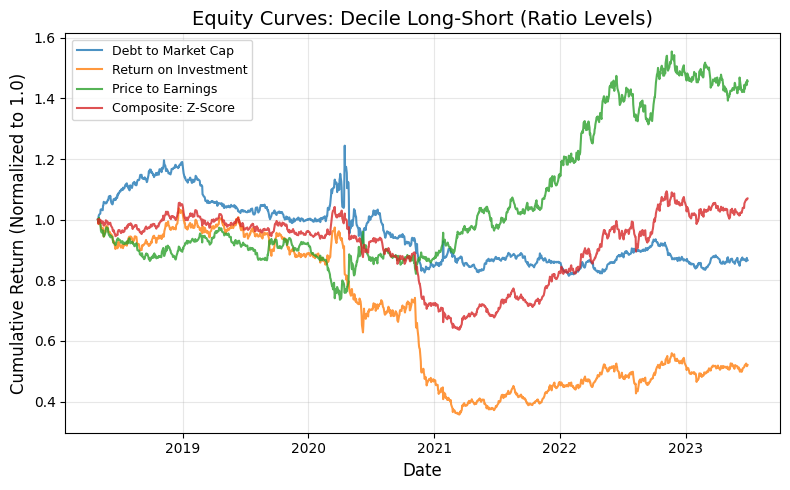

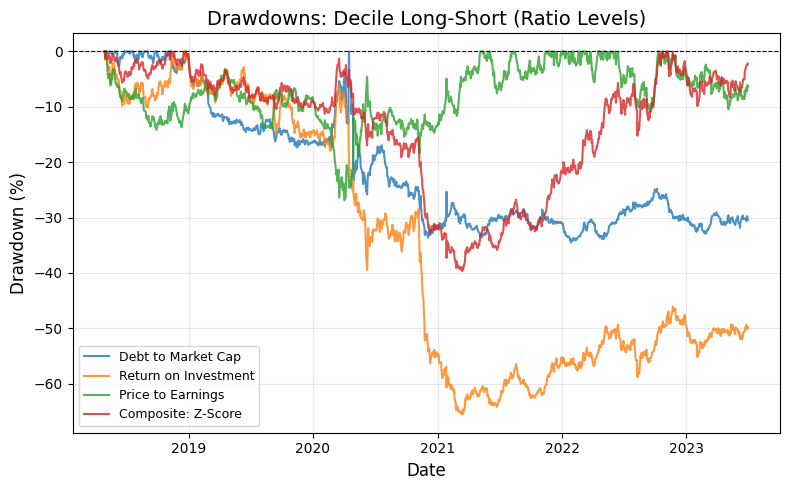

In [212]:
# Equity curves
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in level_backtests.items():
    if sizing != 'equal':
        continue
    equity = bt['capital'] / bt['capital'].iloc[0]
    ax.plot(bt['date'], equity, label=strategy_name, linewidth=1.5, alpha=0.8)

ax.set_title('Equity Curves: Decile Long-Short (Ratio Levels)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Normalized to 1.0)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drawdowns
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in level_backtests.items():
    if sizing != 'equal':
        continue
    dd = compute_drawdown(bt['capital'])
    ax.plot(bt['date'], dd * 100, label=strategy_name, linewidth=1.5, alpha=0.8)

ax.set_title('Drawdowns: Decile Long-Short (Ratio Levels)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## Economic Intuition : Why the P/E Signal Works Post-2021

The upward trend observed in the P&L of the low-P/E (value) long–short strategy since 2021 is therefore correct with what happend to value factor.

The sign convention used in the composite signal—specifically **buying low P/E stocks and shorting high P/E stocks**—is economically well-motivated and consistent with observed market behavior over the sample period, particularly since 2021.

Low P/E stocks are typically classified as **value stocks**, while high P/E stocks are more closely associated with **growth stocks**, whose valuations rely heavily on cash flows far into the future. This distinction became especially important following the COVID-19 period.

During 2020 and early 2021, equity markets were supported by exceptionally **easy monetary policy**, including near-zero policy rates and large-scale asset purchases by the Federal Reserve. In such an environment, discount rates were extremely low, which disproportionately benefited long-duration assets—namely high-growth, high-P/E stocks—because distant cash flows were discounted less aggressively.

Beginning in late 2021, however, the macroeconomic regime shifted. Persistent inflation pressures led the Federal Reserve to **signal and then implement a rapid tightening cycle**, raising policy rates and withdrawing liquidity. As discount rates increased, the present value of long-dated cash flows declined sharply, leading to a relative **valuation compression in growth stocks**. In contrast, value stocks—characterized by lower P/E ratios and cash flows concentrated in the near term—were significantly less sensitive to rising discount rates.

As a result, **value factors rebounded strongly after a prolonged period of underperformance**.

### Compute Ratio Changes

Rank stocks based on changes in ratios rather than levels.

In [213]:
def build_ratio_changes(scores_df, signal_cols, rebalance_dates):
    """Compute changes between consecutive rebalance dates"""
    reb_dates = pd.DatetimeIndex(rebalance_dates).sort_values()
    snap = scores_df[scores_df['date'].isin(reb_dates)].copy()
    snap = snap.sort_values(['ticker', 'date'])
    
    changes = snap[['ticker', 'date']].copy()
    
    for col in signal_cols:
        if col in snap.columns:
            changes[f'{col}_chg'] = snap.groupby('ticker')[col].diff()
    
    return changes.dropna().reset_index(drop=True)

change_signal_cols = [
    'debt_to_mktcap', 'return_on_inv', 'price_to_earnings',
    'score_z_econ']

changes_df = build_ratio_changes(scores, change_signal_cols, rebalance_dates)

### Run Backtests on Ratio Changes

In [214]:
change_strategies = [
    ("Debt/MktCap (change)", "debt_to_mktcap_chg"),
    ("Return on Inv (change)", "return_on_inv_chg"),
    ("Price to Earnings (change)", "price_to_earnings_chg"),
    ("Composite Z-Score (change)", "score_z_econ_chg")
]

change_results = []
change_backtests = {}

for strategy_name, signal_col in change_strategies:
    try:
        bt = backtest_long_short(
            scores_long=changes_df,
            price_wide=price_wide,
            ret_wide=ret_wide,
            signal_col=signal_col,
            rebalance_dates=rebalance_dates,
            sizing='equal',
            funding_rate_annual=FUNDING_RATE_ANNUAL,
        )
        
        metrics = compute_performance_metrics(bt, mkt_ret)
        metrics['Strategy'] = strategy_name
        metrics['Signal'] = signal_col
        metrics['Sizing'] = 'equal'
        
        change_results.append(metrics)
        change_backtests[(strategy_name, 'equal')] = bt
    except Exception as e:
        pass

change_results_df = pd.DataFrame(change_results)
change_results_df = change_results_df.set_index('Strategy')

display_df = change_results_df[display_cols].sort_values('Sharpe', ascending=False)
display(display_df.round(4).style.set_caption("Performance Summary (Sorted by Sharpe)"))

,Sharpe,Sortino,Calmar,Total Return,Annualized Return,Annualized Vol,Max Drawdown,VaR (95%),CVaR (95%),Win Rate,Downside Beta,Avg Gross Exposure,PnL / Notional
Strategy,,,,,,,,,,,,,
Price to Earnings (change),0.750000,1.151300,5.920800,0.648300,0.109000,0.145300,-0.109500,-0.012700,-0.019300,0.506600,0.016000,52.554200,0.251800
Composite Z-Score (change),0.476500,0.631100,1.764800,0.251200,0.049500,0.104000,-0.142300,-0.009700,-0.014400,0.530100,-0.008500,44.204100,0.119800
Return on Inv (change),0.168200,0.220800,0.369600,0.067000,0.019600,0.116600,-0.181300,-0.009800,-0.016400,0.497300,-0.019800,42.024500,0.040000
Debt/MktCap (change),-0.413400,-0.442100,-0.813500,-0.325100,-0.064900,0.156900,-0.399600,-0.012100,-0.024300,0.514500,0.024000,30.713500,-0.218800


### Visualize Change in Ratios Strategies (Equity & Drawdown Plots)

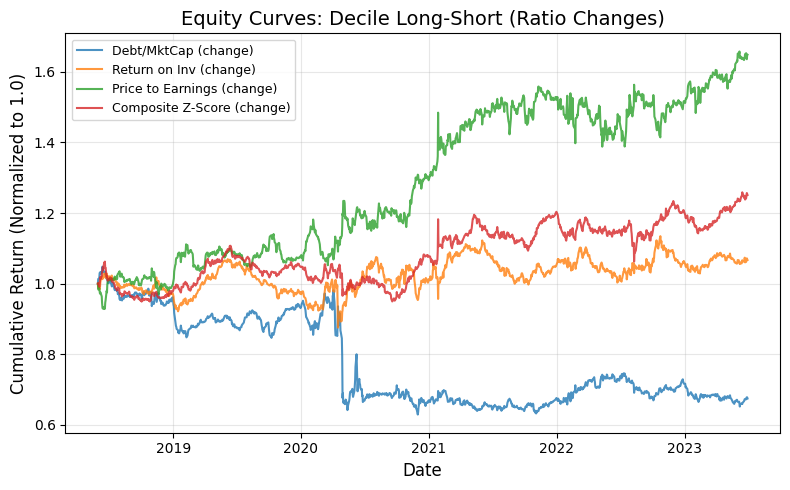

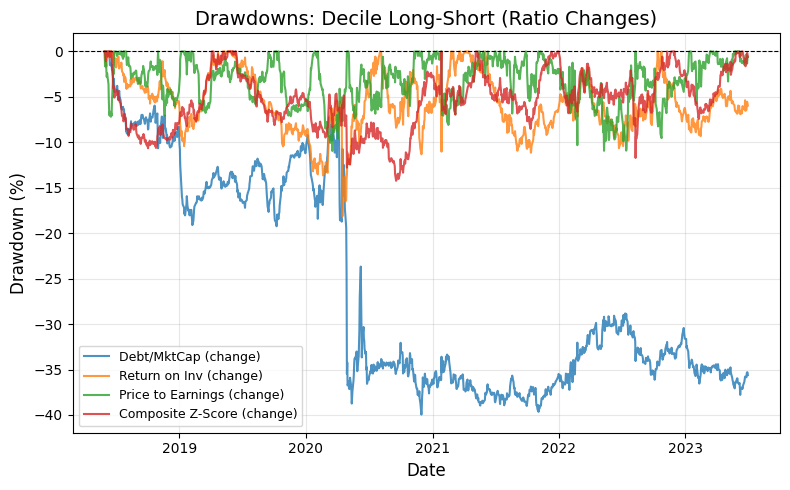

In [215]:
# Equity curves
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in change_backtests.items():
    if sizing != 'equal':
        continue
    equity = bt['capital'] / bt['capital'].iloc[0]
    ax.plot(bt['date'], equity, label=strategy_name, linewidth=1.5, alpha=0.8)

ax.set_title('Equity Curves: Decile Long-Short (Ratio Changes)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Normalized to 1.0)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drawdowns
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in change_backtests.items():
    if sizing != 'equal':
        continue
    dd = compute_drawdown(bt['capital'])
    ax.plot(bt['date'], dd * 100, label=strategy_name, linewidth=1.5, alpha=0.8)

ax.set_title('Drawdowns: Decile Long-Short (Ratio Changes)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### Position Sizing Experiments

Test vigintile sizing variants on the best-performing strategy.

In [216]:
# Find the best strategy from both level and change results
# Combine both dataframes to compare all strategies
all_strategies_combined = pd.concat([
    level_results_df.assign(Source='Level'),
    change_results_df.assign(Source='Change')
])

# Find the strategy with the highest Sharpe ratio
best_overall_idx = all_strategies_combined['Sharpe'].idxmax()
best_strategy_name = best_overall_idx
best_source = all_strategies_combined.loc[best_overall_idx, 'Source']
best_signal_col = all_strategies_combined.loc[best_overall_idx, 'Signal']

# Select the appropriate data source based on whether it's a level or change strategy
if best_source == 'Level':
    scores_long = scores
    strategy_type = 'Ratio Levels'
else:
    scores_long = changes_df
    strategy_type = 'Ratio Changes'

sizing_methods = ['equal', 'rank', 'vigintile_double', 'vigintile_half']
sizing_results = []
sizing_backtests = {}

for sizing in sizing_methods:
    try:
        bt = backtest_long_short(
            scores_long=scores_long,
            price_wide=price_wide,
            ret_wide=ret_wide,
            signal_col=best_signal_col,
            rebalance_dates=rebalance_dates,
            sizing=sizing,
            funding_rate_annual=FUNDING_RATE_ANNUAL,
        )
        
        metrics = compute_performance_metrics(bt, mkt_ret)
        metrics['Strategy'] = best_strategy_name
        metrics['Sizing'] = sizing
        
        sizing_results.append(metrics)
        sizing_backtests[(best_strategy_name, sizing)] = bt
        
    except Exception as e:
        # If an error occurs just skip appending results for this sizing
        continue

sizing_results_df = pd.DataFrame(sizing_results)
sizing_results_df = sizing_results_df.set_index('Sizing')

display_df = sizing_results_df[display_cols].sort_values('Sharpe', ascending=False)
display(display_df.round(4).style.set_caption(f"{best_strategy_name} - Sizing Comparison"))

,Sharpe,Sortino,Calmar,Total Return,Annualized Return,Annualized Vol,Max Drawdown,VaR (95%),CVaR (95%),Win Rate,Downside Beta,Avg Gross Exposure,PnL / Notional
Sizing,,,,,,,,,,,,,
rank,0.883500,1.291000,6.920300,0.968000,0.147100,0.166500,-0.139900,-0.014100,-0.021500,0.514500,0.036700,59.669200,0.334400
vigintile_half,0.758000,1.193800,5.669700,0.637200,0.107100,0.141300,-0.112400,-0.012500,-0.018900,0.502700,0.021000,52.083900,0.250000
equal,0.750000,1.151300,5.920800,0.648300,0.109000,0.145300,-0.109500,-0.012700,-0.019300,0.506600,0.016000,52.554200,0.251800
vigintile_double,0.716500,1.056500,6.083400,0.666200,0.112900,0.157500,-0.109500,-0.013000,-0.020000,0.506600,0.006700,53.392600,0.254100


### Visualize various position sizing methodologies (Equity & Drawdown Plots)

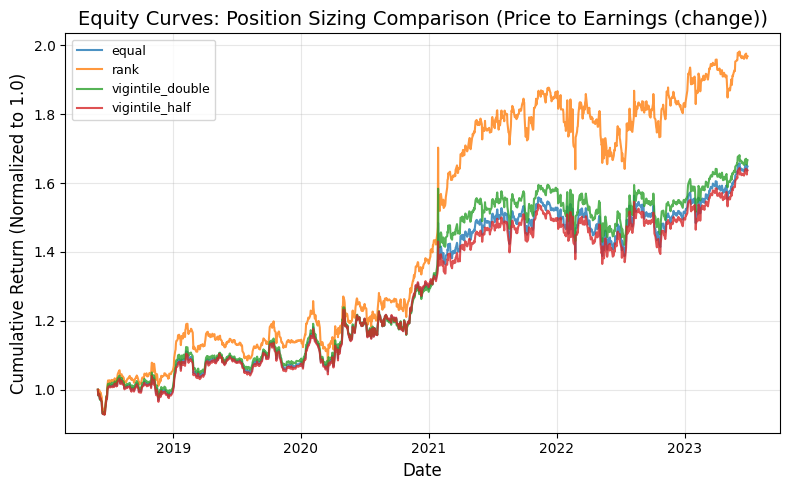

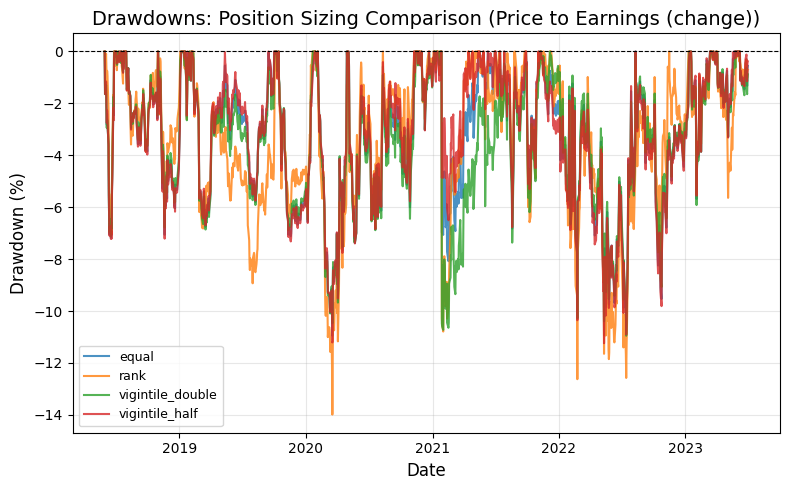

In [217]:
# Equity curves
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in sizing_backtests.items():
    equity = bt['capital'] / bt['capital'].iloc[0]
    ax.plot(bt['date'], equity, label=sizing, linewidth=1.5, alpha=0.8)

ax.set_title(f'Equity Curves: Position Sizing Comparison ({best_strategy_name})', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Normalized to 1.0)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drawdowns
fig, ax = plt.subplots(figsize=(8, 5))

for (strategy_name, sizing), bt in sizing_backtests.items():
    dd = compute_drawdown(bt['capital'])
    ax.plot(bt['date'], dd * 100, label=sizing, linewidth=1.5, alpha=0.8)

ax.set_title(f'Drawdowns: Position Sizing Comparison ({best_strategy_name})', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown (%)', fontsize=12)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## Limitations of Quantile-Based Trading and the Role of Portfolio Optimization

Quantile-based trading strategies are useful as diagnostic tools and as simple, interpretable implementations of cross-sectional signals. However, by construction, they are not designed to produce portfolios that maximize risk-adjusted returns.

A quantile strategy typically allocates capital only to assets in the extreme tails of a signal distribution (e.g., top and bottom deciles) and assigns zero weight to the remainder of the universe. This introduces several limitations.

First, quantile trading **does not explicitly optimize for Sharpe ratio**. The strategy mechanically concentrates exposure in assets with the most extreme signals, regardless of their covariance structure or contribution to portfolio risk. As a result, stocks in the middle of the signal distribution—which may have lower expected returns but provide meaningful diversification benefits—are excluded entirely. This truncation can increase portfolio variance without a commensurate increase in expected return.

Second, quantile portfolios implicitly assume that signal strength dominates all other considerations. In reality, even moderately predictive signals can add value when combined appropriately with other signals and balanced against correlation structure. Discrete long–short buckets ignore this continuous trade-off.

**In practice**, systematic portfolios are constructed by **combining multiple signals into a single expected return forecast** (alpha) and explicitly accounting for risk through a covariance matrix. Because empirical covariance estimates are noisy and often ill-conditioned in high dimensions, they are typically **shrunk or regularized**, often using statistical factor models (e.g., PCA-based) or economic factor models. Shrinkage reduces estimation error and improves numerical stability, enabling more reliable optimization.

Portfolio weights are then determined by solving a regularized mean–variance optimization problem, often augmented with transaction costs. A stylized objective takes the form:
$$
\max_{w}
\;\;
w^\top \mu
\;-\;
\frac{\lambda}{2}\, w^\top \Sigma w
\;-\;
\kappa \, C(w - w_{t-1}),
$$
where:
- $w$ denotes portfolio weights,
- $\mu$ is the vector of expected returns (combined alpha),
- $\Sigma$ is a shrunk or factor-based covariance matrix,
- $\lambda$ controls risk aversion,
- $C(\cdot)$ is a convex transaction cost function,
- $w_{t-1}$ are previous-period weights.

This formulation explicitly trades off expected return, risk, and trading costs, and naturally assigns non-zero weights to assets across the signal spectrum when doing so improves the portfolio’s overall risk-adjusted performance.

Quantile strategies therefore serve primarily as **signal validation tools**—useful for understanding monotonicity, robustness, and economic intuition—but are generally inferior to optimized portfolios when the objective is to maximize Sharpe ratio under realistic risk and cost constraints.


### Snapshots Across All Analysis

In [218]:
# Display all strategies (Ratio Levels) with annotation
level_results_annotated = level_results_df[['Sharpe', 'Sortino', 'Total Return', 'Max Drawdown']].sort_values('Sharpe', ascending=False).round(4)
level_results_annotated.title = "All Strategies (Ratio Levels)"
display(level_results_annotated.style.set_caption(level_results_annotated.title))

# Display all strategies (Ratio Changes) with annotation
change_results_annotated = change_results_df[['Sharpe', 'Sortino', 'Total Return', 'Max Drawdown']].sort_values('Sharpe', ascending=False).round(4)
change_results_annotated.title = "All Strategies (Ratio Changes)"
display(change_results_annotated.style.set_caption(change_results_annotated.title))

# Display all sizing methods with annotation, with explicit strategy used in brackets
sizing_results_annotated = sizing_results_df[['Sharpe', 'Sortino', 'Max Drawdown']].sort_values('Sharpe', ascending=False).round(4)
sizing_results_annotated.title = f"Position Sizing Method Comparison ({best_strategy_name})"
display(sizing_results_annotated.style.set_caption(sizing_results_annotated.title))

# Create and display all strategies together with strategy type annotated
all_strategies = pd.concat([
    level_results_df.assign(Type='Level'),
    change_results_df.assign(Type='Change'),
    sizing_results_df.assign(Type=f'Sizing ({best_strategy_name})')
])
all_strategies_annotated = all_strategies[['Sharpe', 'Sortino', 'Total Return', 'Max Drawdown', 'Type']].sort_values('Sharpe', ascending=False).round(4)
all_strategies_annotated.title = "All Strategies Across Types"
display(all_strategies_annotated.style.set_caption(all_strategies_annotated.title))


,Sharpe,Sortino,Total Return,Max Drawdown
Strategy,,,,
Price to Earnings,0.585500,0.979600,0.456300,-0.268900
Composite: Z-Score,0.166700,0.218800,0.070000,-0.396500
Debt to Market Cap,-0.139900,-0.174400,-0.134100,-0.345200
Return on Investment,-0.531600,-0.633600,-0.479500,-0.656000


,Sharpe,Sortino,Total Return,Max Drawdown
Strategy,,,,
Price to Earnings (change),0.750000,1.151300,0.648300,-0.109500
Composite Z-Score (change),0.476500,0.631100,0.251200,-0.142300
Return on Inv (change),0.168200,0.220800,0.067000,-0.181300
Debt/MktCap (change),-0.413400,-0.442100,-0.325100,-0.399600


,Sharpe,Sortino,Max Drawdown
Sizing,,,
rank,0.883500,1.291000,-0.139900
vigintile_half,0.758000,1.193800,-0.112400
equal,0.750000,1.151300,-0.109500
vigintile_double,0.716500,1.056500,-0.109500


,Sharpe,Sortino,Total Return,Max Drawdown,Type
rank,0.883500,1.291000,0.968000,-0.139900,Sizing (Price to Earnings (change))
vigintile_half,0.758000,1.193800,0.637200,-0.112400,Sizing (Price to Earnings (change))
Price to Earnings (change),0.750000,1.151300,0.648300,-0.109500,Change
equal,0.750000,1.151300,0.648300,-0.109500,Sizing (Price to Earnings (change))
vigintile_double,0.716500,1.056500,0.666200,-0.109500,Sizing (Price to Earnings (change))
Price to Earnings,0.585500,0.979600,0.456300,-0.268900,Level
Composite Z-Score (change),0.476500,0.631100,0.251200,-0.142300,Change
Return on Inv (change),0.168200,0.220800,0.067000,-0.181300,Change
Composite: Z-Score,0.166700,0.218800,0.070000,-0.396500,Level
Debt to Market Cap,-0.139900,-0.174400,-0.134100,-0.345200,Level


## Results Summary, Learnings, Insights, and Takeaways

This notebook implements and evaluates quantile-based long–short strategies using three fundamental ratios—Debt to Market Capitalization, Return on Investment, and Price-to-Earnings—along with composite signals. The analysis spans January 2018 through June 2023 and focuses on cross-sectional return predictability rather than market timing.

### Key Empirical Results

At the level of raw ratios, the **Price-to-Earnings (P/E) strategy** dominates the other single-ratio strategies, delivering the highest Sharpe ratio and the strongest post-2021 performance. In contrast, standalone Debt/MktCap and ROI strategies perform poorly over the sample period, highlighting that not all economically intuitive ratios translate into effective standalone signals when implemented mechanically via quantile portfolios.

When shifting from **ratio levels to ratio changes**, performance improves materially. The **change in P/E** signal is the strongest strategy overall, achieving the highest Sharpe ratio across all tested specifications.

### Economic Interpretation

The strong performance of low-P/E strategy since 2021 aligns with real-world value factor performance. Following years of accommodative monetary policy, the Federal Reserve’s tightening cycle led to higher discount rates, disproportionately penalizing long-duration growth stocks. As a result, value-oriented stocks—characterized by lower valuation multiples—experienced a relative rebound. The results observed in this notebook are therefore consistent with known macroeconomic mechanisms rather than being artifacts of the sample period.

### Methodological Insights

Several important methodological lessons emerge:

1. **Predicting relative returns is distinct from predicting market direction.**  
   The strategies here are exploiting cross-sectional dispersion in expected returns, not by timing the market. Long–short construction removes much of the market-level movement, allowing firm-level characteristics to capture relative performance.

2. **Quantile portfolios emphasize signal extremes but sacrifice efficiency.**  
   By construction, quantile trading concentrates exposure in the tails of the signal distribution and discards information from the middle. This can increase volatility and ignore diversification benefits that would be captured by a continuous weighting scheme.

3. **Dollar neutrality does not imply risk neutrality.**  
   Although the portfolios are dollar-neutral, residual exposures to market, sector, and style factors remain. This helps explain drawdowns observed during periods of stress and reinforces the need for explicit risk modeling in production settings.

4. **Position sizing materially affects outcomes.**  
   Rank-based and moderated vigintile sizing outperform equal-weighting, indicating that smooth scaling with signal strength is preferable to binary inclusion rules.

### Practical Takeaways

Quantile strategies are best viewed as **diagnostic and validation tools** rather than fully optimized investment solutions. They are effective for testing monotonicity, economic intuition, and signal robustness, but they are not designed to maximize risk-adjusted returns.

In real-world systematic portfolios, signals such as those studied here are typically combined into a unified alpha forecast, paired with a **shrunk or factor-based covariance matrix** to reduce noise, and deployed through **regularized mean–variance optimization** with transaction costs explicitly embedded. This framework allows for continuous weighting, improved diversification, and better control of unintended risk exposures.

Overall, the analysis demonstrates that valuation-based signals—particularly changes in valuation—contain economically meaningful information about relative returns. However, realizing their full potential requires moving beyond quantile trading toward integrated portfolio construction and risk management.